In [10]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

PKLs = []
PKL_titles = []
DIR = "./sonar/"
for file in os.listdir(DIR):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

In [11]:
list_idx_rwmh = []
list_idx_ar = []
for i in range(n):
    if 'gamma' in PKLs[i]['config']['proposal']:
        list_idx_rwmh.append(i)
    else:
        list_idx_ar.append(i)

In [12]:
def make_acf(samples, coord=0, max_order=20):
    """
    Make ACF function for different iterations given the samples
    """
    samples = jnp.swapaxes(samples, 0, 1)
    samples = samples.reshape((samples.shape[0], samples.shape[1]*samples.shape[2], samples.shape[3], samples.shape[4]))
    global_mean = samples.mean(axis=[1, 2])
    global_mean = global_mean.reshape((samples.shape[0], 1, 1, samples.shape[3]))
    diff0 = samples- global_mean
    diff0 = diff0.reshape((diff0.shape[0], diff0.shape[1], diff0.shape[2], 1, diff0.shape[3]))
    var0 = jnp.mean(diff0@jnp.swapaxes(diff0, -1, -2), axis=[2])
    def fcorr(k):
        diff = samples[:,:,:-k] - global_mean
        diffk = samples[:,:,k:] - global_mean
        diff = diff.reshape((diff.shape[0], diff.shape[1], diff.shape[2], 1, diff.shape[3]))
        diffk = diffk.reshape((diffk.shape[0], diffk.shape[1], diffk.shape[2], diffk.shape[3], 1))
        prod = diff@diffk
        vark = jnp.mean(prod, axis=[2])
        corr = jnp.mean(vark/var0, axis=[-3]) 
        return corr
    return np.array([fcorr(k)[:,coord,coord][1:] for k in range(1, max_order)])


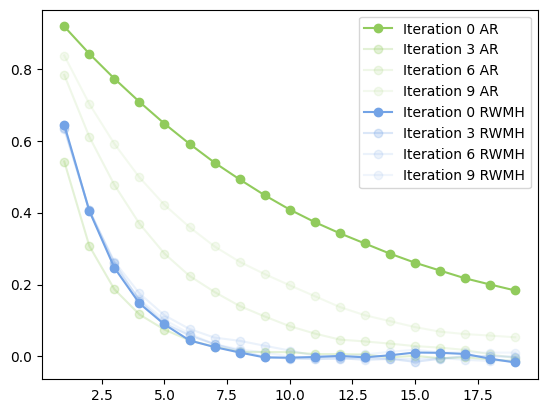

In [13]:
NUM_COLORS = 30
color_set = set()
while len(color_set)<NUM_COLORS:
    random_integers = [np.random.randint(0, 255)/255 for _ in range(3)]
    color_set.add(tuple(random_integers))
color_set = list(color_set)

labels = ['AR', 'RWMH']

for _idx, l in enumerate([list_idx_ar, list_idx_rwmh]):
    for idx in l:
        for it in range(0, min(PKLs[idx]['res'][0].shape[1], 10)):
            if it % 3==0:
                acfs = make_acf(samples = PKLs[idx]['res'][0])
                plt.plot(np.arange(1, 20), acfs[:,it-1], marker='o',label=f"Iteration {it} {labels[_idx]}", color=color_set[_idx], alpha=1/(it+1))
        plt.legend()